This one does histogram without distinguishing types

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#preprocessing
import os
import torch
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# ----------------------------
# CONFIG
# ----------------------------
root = "/content/drive/MyDrive/clean_dataset/L_150"
save_path = "/content/drive/MyDrive/processed_dataset.pt"

n_bins = 20
r_max = 35.0
bins = np.linspace(0, r_max, n_bins+1)

# ----------------------------
# AA → 6-bead mapping
# ----------------------------
aa_to_type = {
    'K':0, 'R':0, 'H':0,
    'S':1, 'T':1, 'N':1, 'Q':1,
    'G':2, 'P':2, 'C':2,
    'A':3, 'V':3, 'I':3, 'L':3, 'M':3,
    'D':4, 'E':4,
    'F':5, 'Y':5, 'W':5
}

# ----------------------------
# HISTOGRAM FUNCTION
# ----------------------------
def compute_hist(file_path):
    hist = np.zeros(n_bins)

    with open(file_path) as f:
        lines = f.readlines()

    frames = []
    i = 0
    while i < len(lines):
        if "ITEM: ATOMS" in lines[i]:
            i += 1
            pos = []
            while i < len(lines) and not lines[i].startswith("ITEM"):
                parts = lines[i].split()
                x, y, z = float(parts[2]), float(parts[3]), float(parts[4])
                pos.append([x, y, z])
                i += 1
            frames.append(np.array(pos))
        else:
            i += 1

    # compute pair distances
    for frame in frames:
        N = len(frame)
        for i in range(N):
            for j in range(i+1, N):
                r = np.linalg.norm(frame[i] - frame[j])
                b = np.searchsorted(bins, r) - 1
                if 0 <= b < n_bins:
                    hist[b] += 1

    # normalize
    hist = hist / (hist.sum() + 1e-8)
    return hist

# ----------------------------
# BUILD DATASET
# ----------------------------
data = []
count = 0

for comp in os.listdir(root):
    comp_path = os.path.join(root, comp)
    if not os.path.isdir(comp_path): continue

    for pattern in os.listdir(comp_path):
        pattern_path = os.path.join(comp_path, pattern)
        if not os.path.isdir(pattern_path): continue

        for seq in os.listdir(pattern_path):
            seq_path = os.path.join(pattern_path, seq)
            if not os.path.isdir(seq_path): continue

            seq_file  = os.path.join(seq_path, "seq_spaced.txt")
            rg_file   = os.path.join(seq_path, "Rg.out")
            traj_file = os.path.join(seq_path, "result.lammpstrj")

            if not (os.path.exists(seq_file) and os.path.exists(rg_file) and os.path.exists(traj_file)):
                continue

            # ----------------------------
            # LOAD SEQUENCE
            # ----------------------------
            with open(seq_file) as f:
                seq_list = [line.strip() for line in f]

            seq_tensor = torch.tensor(
                [aa_to_type.get(a, 2) for a in seq_list],
                dtype=torch.long
            )

            # ----------------------------
            # LOAD Rg (post-equilibration avg)
            # ----------------------------
            with open(rg_file) as f:
                lines = f.readlines()

            data_lines = [l for l in lines if not l.startswith("#")]
            rg_vals = [float(l.split()[1]) for l in data_lines if len(l.split()) >= 2]

            if len(rg_vals) < 10:
                continue  # skip bad samples

            rg_vals = rg_vals[len(rg_vals)//2:]  # last 50%
            rg = sum(rg_vals) / len(rg_vals)

            # ----------------------------
            # COMPUTE HISTOGRAM
            # ----------------------------
            hist = compute_hist(traj_file)

            # ----------------------------
            # STORE
            # ----------------------------
            data.append({
                "seq": seq_tensor,
                "rg": torch.tensor(rg, dtype=torch.float32),
                "dist": torch.tensor(hist, dtype=torch.float32)
            })

            count += 1
            if count % 10 == 0:
                print(f"Processed {count} samples", end="\r")

# ----------------------------
# SAVE
# ----------------------------
torch.save(data, save_path)

print("\n✅ DONE")
print("Saved to:", save_path)
print("Total samples:", len(data))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Loading
import torch
from torch.utils.data import Dataset, DataLoader

# ----------------------------
# FAST DATASET (loads precomputed tensors)
# ----------------------------
class FastDataset(Dataset):
    def __init__(self, path):
        self.data = torch.load(path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        d = self.data[idx]
        return d["seq"], d["rg"], d["dist"]

# ----------------------------
# LOAD DATA
# ----------------------------
dataset = FastDataset("/content/drive/MyDrive/processed_dataset.pt")

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

# ----------------------------
# DEVICE
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dataset size:", len(dataset))

Dataset size: 800


In [ ]:
#model
import torch.nn as nn
import torch.nn.functional as F

class RgModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.d_model = 64
        self.n_bins = 20

        # embedding (6 bead types)
        self.embedding = nn.Embedding(6, self.d_model)

        # transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=4,
            dim_feedforward=128,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # pairwise MLP → distance bins
        self.pair_mlp = nn.Sequential(
            nn.Linear(2*self.d_model, 128),
            nn.ReLU(),
            nn.Linear(128, self.n_bins)
        )

        # distance bin centers squared
        r = torch.linspace(1.0, 35.0, self.n_bins)
        self.register_buffer("r2", r**2)

    def forward(self, x, return_dist=False):
        h = self.embedding(x)
        h = self.transformer(h)

        B, L, D = h.shape

        hi = h.unsqueeze(2).expand(B, L, L, D)
        hj = h.unsqueeze(1).expand(B, L, L, D)

        pair = torch.cat([hi, hj], dim=-1)

        # predicted distributions
        dist = F.softplus(self.pair_mlp(pair))

        # compute Rg
        rg2 = (dist * self.r2).sum(dim=-1)
        rg2 = rg2.mean(dim=(1,2))
        rg = torch.sqrt(rg2 + 1e-8)

        if return_dist:
            return rg, dist
        else:
            return rg

# ----------------------------
# INIT
# ----------------------------
model = RgModel().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

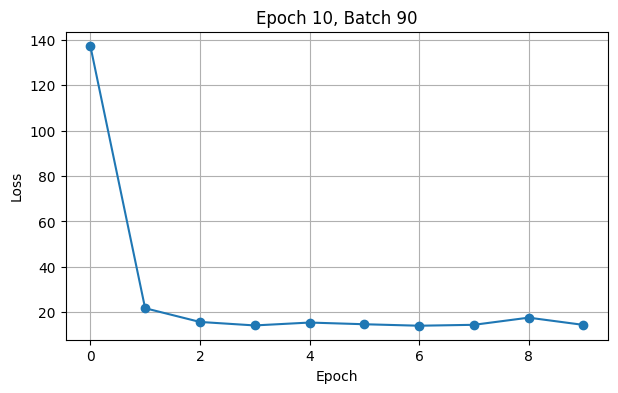

Epoch 10, Batch 90, Loss: 14.3642


In [ ]:

#training loop
from IPython.display import clear_output
import matplotlib.pyplot as plt
import torch.nn.functional as F

# --- NEW: differentiable Gaussian smoothing ---
def smooth_torch(x, sigma=1.2):
    kernel_size = int(4 * sigma + 1)
    if kernel_size % 2 == 0:
        kernel_size += 1

    x_range = torch.arange(kernel_size, device=x.device) - kernel_size // 2
    kernel = torch.exp(-0.5 * (x_range / sigma) ** 2)
    kernel = kernel / kernel.sum()

    kernel = kernel.view(1, 1, -1)

    x = x.unsqueeze(1)  # (B,1,N)
    x = F.conv1d(x, kernel, padding=kernel_size // 2)

    return x.squeeze(1)


epochs = 10
lambda_dist = 0.1
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for i, (x, y_rg, y_dist) in enumerate(loader):
        x = x.to(device)
        y_rg = y_rg.to(device)
        y_dist = y_dist.to(device)

        # forward
        pred_rg, dist = model(x, return_dist=True)

        # collapse pairwise → global dist
        pred_dist = dist.mean(dim=(1,2))
        pred_dist = pred_dist / (pred_dist.sum(dim=1, keepdim=True) + 1e-8)

        # --- NEW: smooth both distributions ---
        pred_smooth = smooth_torch(pred_dist)
        true_smooth = smooth_torch(y_dist)

        # re-normalize after smoothing
        pred_smooth = pred_smooth / (pred_smooth.sum(dim=1, keepdim=True) + 1e-8)
        true_smooth = true_smooth / (true_smooth.sum(dim=1, keepdim=True) + 1e-8)

        # losses (ONLY CHANGE HERE)
        loss_rg = loss_fn(pred_rg, y_rg)
        loss_dist = F.mse_loss(pred_smooth, true_smooth)

        loss = loss_rg + lambda_dist * loss_dist

        # backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # visualization
        if i % 10 == 0:
            clear_output(wait=True)

            avg_loss = total_loss / (i + 1)

            plt.figure(figsize=(7,4))
            plt.plot(train_losses + [avg_loss], marker='o')
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title(f"Epoch {epoch+1}, Batch {i}")
            plt.grid()
            plt.show()

            print(f"Epoch {epoch+1}, Batch {i}, Loss: {avg_loss:.4f}")

    train_losses.append(total_loss / len(loader))

True Rg: 22.26 | Pred Rg: 30.99


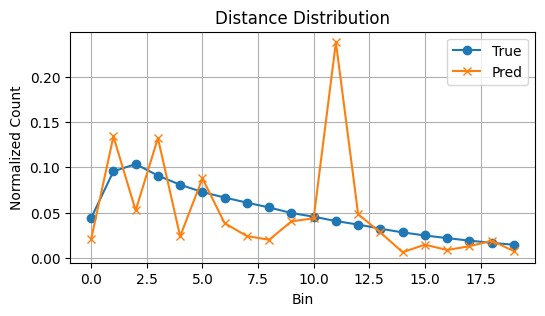

True Rg: 35.66 | Pred Rg: 36.55


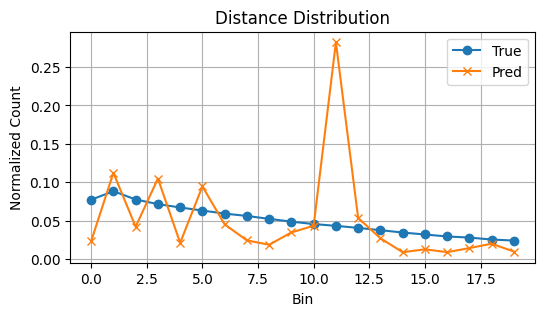

True Rg: 27.60 | Pred Rg: 28.59


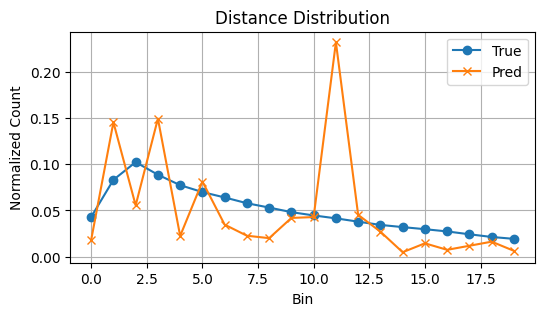

True Rg: 23.19 | Pred Rg: 29.07


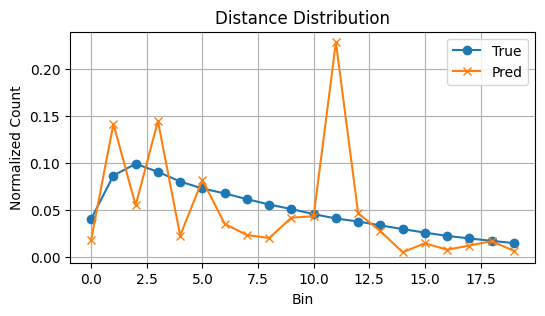

True Rg: 35.19 | Pred Rg: 36.92


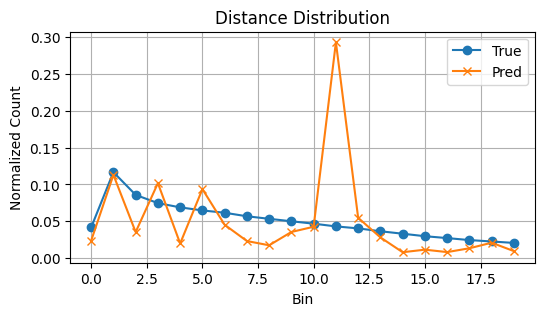

In [ ]:
#eval
import random
import matplotlib.pyplot as plt

model.eval()

n_samples = 5
indices = random.sample(range(len(dataset)), n_samples)

true_rg_list = []
pred_rg_list = []

for idx in indices:
    seq, true_rg, true_dist = dataset[idx]

    x = seq.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_rg, dist = model(x, return_dist=True)

    pred_rg = pred_rg.item()
    true_rg = true_rg.item()

    pred_dist = dist[0].mean(dim=(0,1)).cpu()
    pred_dist = pred_dist / (pred_dist.sum() + 1e-8)

    # store Rg
    true_rg_list.append(true_rg)
    pred_rg_list.append(pred_rg)

    # ----------------------------
    # PRINT
    # ----------------------------
    print(f"True Rg: {true_rg:.2f} | Pred Rg: {pred_rg:.2f}")

    # ----------------------------
    # PLOT DISTRIBUTIONS
    # ----------------------------
    plt.figure(figsize=(6,3))
    plt.plot(true_dist.numpy(), label="True", marker='o')
    plt.plot(pred_dist.numpy(), label="Pred", marker='x')
    plt.title("Distance Distribution")
    plt.xlabel("Bin")
    plt.ylabel("Normalized Count")
    plt.legend()
    plt.grid()
    plt.show()

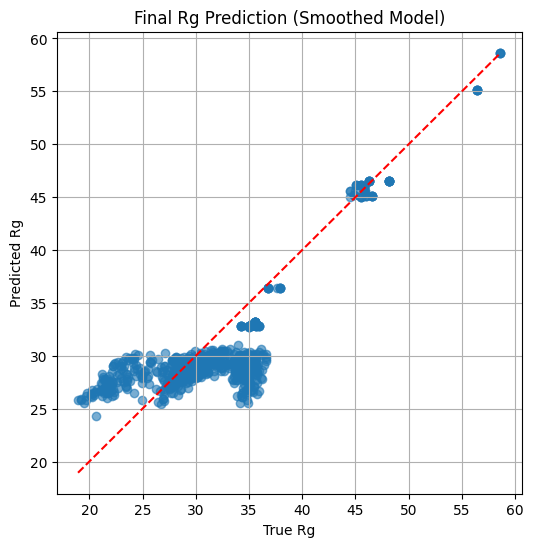

MAE: 3.072
RMSE: 3.877
Correlation: 0.832
Pred std: 5.548


In [ ]:

# ============================
# SAVE MODEL
# ============================
torch.save(model.state_dict(), "model_smoothed.pth")

# ============================
# EVALUATION
# ============================
model.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for x, y_rg, _ in loader:
        x = x.to(device)
        y_rg = y_rg.to(device)

        pred_rg = model(x)

        all_true.append(y_rg.cpu())
        all_pred.append(pred_rg.cpu())

all_true = torch.cat(all_true)
all_pred = torch.cat(all_pred)

# ----------------------------
# PLOT
# ----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(all_true, all_pred, alpha=0.6)

minv = min(all_true.min(), all_pred.min())
maxv = max(all_true.max(), all_pred.max())

plt.plot([minv, maxv], [minv, maxv], 'r--')

plt.xlabel("True Rg")
plt.ylabel("Predicted Rg")
plt.title("Final Rg Prediction (Smoothed Model)")

plt.grid()
plt.show()

# ----------------------------
# METRICS
# ----------------------------
mae = (all_true - all_pred).abs().mean().item()
rmse = torch.sqrt(((all_true - all_pred)**2).mean()).item()
corr = torch.corrcoef(torch.stack([all_true, all_pred]))[0,1].item()

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Correlation: {corr:.3f}")
print(f"Pred std: {all_pred.std().item():.3f}")
